<a href="https://colab.research.google.com/github/santiagoquinterosolanoelectronic123/ALSE_Proyectos_Entrega_3/blob/main/IABO_Tarea_1_Corte_2_JG%2C_JO_%26_SQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1 - Corte 2° - IABO: Creación de Dataset mediante gestos de la mano

Integrantes: Juan Gomez, Juliana Ombita y Santiago Quintero

In [ ]:

# 1. Clonar el repositorio público desde GitHub
!git clone https://github.com/santiagoquinterosolanoelectronic123/Creaci-n-de-Dataset_IMU_IABO_SQS_JG_JO.git

# 2. Importación de librerías esenciales para la tarea
import os
import glob
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(" Repositorio clonado y librerías cargadas exitosamente.")

Cloning into 'Creaci-n-de-Dataset_IMU_IABO_SQS_JG_JO'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 85 (delta 4), reused 85 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (85/85), 163.70 KiB | 9.63 MiB/s, done.
Resolving deltas: 100% (4/4), done.
 Repositorio clonado y librerías cargadas exitosamente.


In [ ]:
def calcular_entropia(señal, num_bins=10):
    """Calcula la entropía de Shannon basada en el histograma de la señal."""
    counts, _ = np.histogram(señal, bins=num_bins)
    prob = counts / np.sum(counts)
    prob = prob[prob > 0]  # Filtrar probabilidades cero
    return -np.sum(prob * np.log2(prob))

# Ruta base del repositorio clonado
ruta_base = "Creaci-n-de-Dataset_IMU_IABO_SQS_JG_JO/data/raw"

ejes = ['aX', 'aY', 'aZ', 'gX', 'gY', 'gZ']
lista_caracteristicas = []

# Recorrer cada carpeta de gesto (gesto_1, gesto_2, ..., gesto_5)
carpetas_gestos = sorted(glob.glob(os.path.join(ruta_base, "gesto_*")))

for ruta_gesto in carpetas_gestos:
    nombre_gesto = os.path.basename(ruta_gesto)
    archivos_csv = glob.glob(os.path.join(ruta_gesto, "*.csv"))

    for archivo in archivos_csv:
        df = pd.read_csv(archivo)

        # Limpiar espacios en los nombres de las columnas
        df.columns = df.columns.str.strip()

        vector_caracteristicas = {'Gesto': nombre_gesto, 'Archivo': os.path.basename(archivo)}

        # Calcular las 6 métricas estadísticas para cada eje de la IMU
        for eje in ejes:
            datos = df[eje].values

            vector_caracteristicas[f'{eje}_media'] = np.mean(datos)
            vector_caracteristicas[f'{eje}_varianza'] = np.var(datos)
            vector_caracteristicas[f'{eje}_curtosis'] = stats.kurtosis(datos)
            vector_caracteristicas[f'{eje}_simetria'] = stats.skew(datos)
            vector_caracteristicas[f'{eje}_entropia'] = calcular_entropia(datos)
            vector_caracteristicas[f'{eje}_energia'] = np.sum(datos ** 2)

        lista_caracteristicas.append(vector_caracteristicas)

# Crear el DataFrame consolidado
df_features = pd.DataFrame(lista_caracteristicas)

# Guardar la matriz de características en formato CSV
df_features.to_csv("features.csv", index=False)

print(f" Matriz de características generada con éxito: {df_features.shape[0]} ventanas procesadas.")
print(f" Archivo 'features.csv' guardado en el entorno de Colab.\n")
df_features.head()

 Matriz de características generada con éxito: 75 ventanas procesadas.
 Archivo 'features.csv' guardado en el entorno de Colab.



,Gesto,Archivo,aX_media,aX_varianza,aX_curtosis,aX_simetria,aX_entropia,aX_energia,aY_media,aY_varianza,...,gY_curtosis,gY_simetria,gY_entropia,gY_energia,gZ_media,gZ_varianza,gZ_curtosis,gZ_simetria,gZ_entropia,gZ_energia
0,gesto_1,ventana_01.csv,0.010121,4.272057e-07,-0.320504,0.511554,2.974635,0.012241,-0.021266,1.266072e-05,...,0.852890,-0.365671,2.771437,4.045399,0.082063,0.269185,11.768134,-2.748865,1.841469,32.834395
1,gesto_1,ventana_11.csv,0.011441,6.656154e-07,-0.023215,-0.202219,2.782569,0.015656,-0.018242,1.601260e-06,...,-0.233013,0.156287,2.149710,0.648101,0.046671,0.007932,-0.231278,0.168802,2.564266,1.203140
2,gesto_1,ventana_09.csv,0.011734,1.509485e-06,0.110102,0.632303,2.935404,0.016566,-0.019602,4.499493e-06,...,6.300641,-1.847440,2.013715,10.926312,0.071291,0.212140,14.721135,-2.399586,1.795356,25.849454
3,gesto_1,ventana_14.csv,0.011903,3.945315e-07,-0.534337,0.231197,2.830816,0.016906,-0.018068,5.292324e-07,...,0.110703,0.145807,2.146554,0.681614,0.055390,0.008451,0.863057,0.378912,2.578671,1.370817
4,gesto_1,ventana_05.csv,0.010866,7.637709e-07,5.441641,1.072981,2.196355,0.014140,-0.019850,1.441659e-06,...,0.876672,-0.963811,2.615276,2.741646,0.046674,0.081936,11.298711,-2.060360,1.829201,10.009591


In [ ]:
# Guardar la matriz de características en formato CSV y Excel
df_features.to_csv("features.csv", index=False)
df_features.to_excel("features.xlsx", index=False)

print(f" Matriz de características generada con éxito: {df_features.shape[0]} ventanas procesadas.")
print(f" Archivos 'features.csv' y 'features.xlsx' guardados en el entorno de Colab.\n")
df_features.head()

 Matriz de características generada con éxito: 75 ventanas procesadas.
 Archivos 'features.csv' y 'features.xlsx' guardados en el entorno de Colab.



,Gesto,Archivo,aX_media,aX_varianza,aX_curtosis,aX_simetria,aX_entropia,aX_energia,aY_media,aY_varianza,...,gY_curtosis,gY_simetria,gY_entropia,gY_energia,gZ_media,gZ_varianza,gZ_curtosis,gZ_simetria,gZ_entropia,gZ_energia
0,gesto_1,ventana_01.csv,0.010121,4.272057e-07,-0.320504,0.511554,2.974635,0.012241,-0.021266,1.266072e-05,...,0.852890,-0.365671,2.771437,4.045399,0.082063,0.269185,11.768134,-2.748865,1.841469,32.834395
1,gesto_1,ventana_11.csv,0.011441,6.656154e-07,-0.023215,-0.202219,2.782569,0.015656,-0.018242,1.601260e-06,...,-0.233013,0.156287,2.149710,0.648101,0.046671,0.007932,-0.231278,0.168802,2.564266,1.203140
2,gesto_1,ventana_09.csv,0.011734,1.509485e-06,0.110102,0.632303,2.935404,0.016566,-0.019602,4.499493e-06,...,6.300641,-1.847440,2.013715,10.926312,0.071291,0.212140,14.721135,-2.399586,1.795356,25.849454
3,gesto_1,ventana_14.csv,0.011903,3.945315e-07,-0.534337,0.231197,2.830816,0.016906,-0.018068,5.292324e-07,...,0.110703,0.145807,2.146554,0.681614,0.055390,0.008451,0.863057,0.378912,2.578671,1.370817
4,gesto_1,ventana_05.csv,0.010866,7.637709e-07,5.441641,1.072981,2.196355,0.014140,-0.019850,1.441659e-06,...,0.876672,-0.963811,2.615276,2.741646,0.046674,0.081936,11.298711,-2.060360,1.829201,10.009591


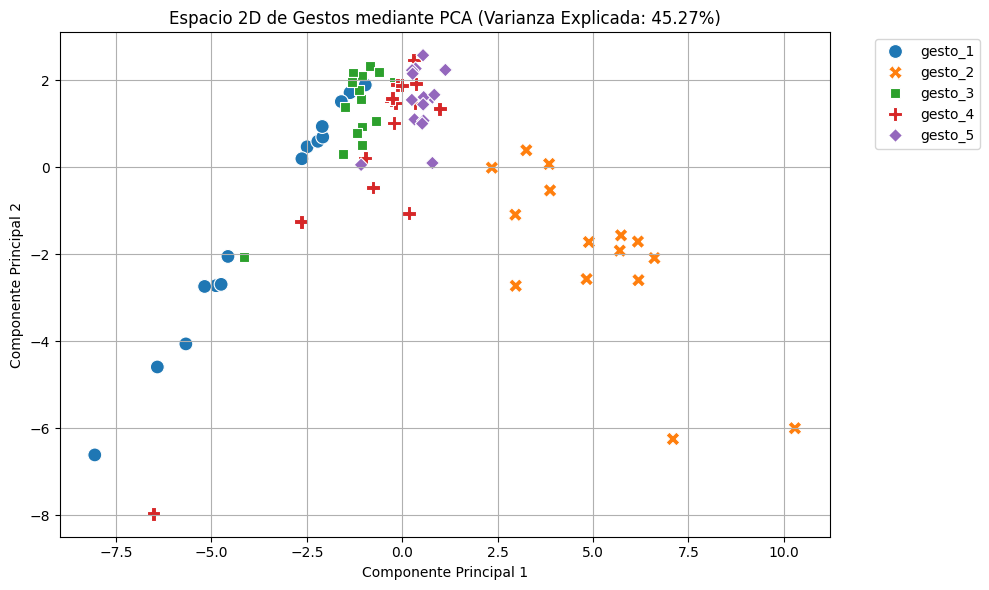

In [ ]:
# Separar variables predictoras (X) y variable objetivo (y)
X_cols = [col for col in df_features.columns if col not in ['Gesto', 'Archivo']]
X = df_features[X_cols]
y = df_features['Gesto']

# 1. Normalizar las características (media 0, varianza 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. PCA para espacio 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# 3. PCA para espacio 3D
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# --- GRÁFICA 2D ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca_2d[:, 0], y=X_pca_2d[:, 1],
    hue=y, palette='tab10', style=y, s=100
)
plt.title(f'Espacio 2D de Gestos mediante PCA (Varianza Explicada: {sum(pca_2d.explained_variance_ratio_)*100:.2f}%)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


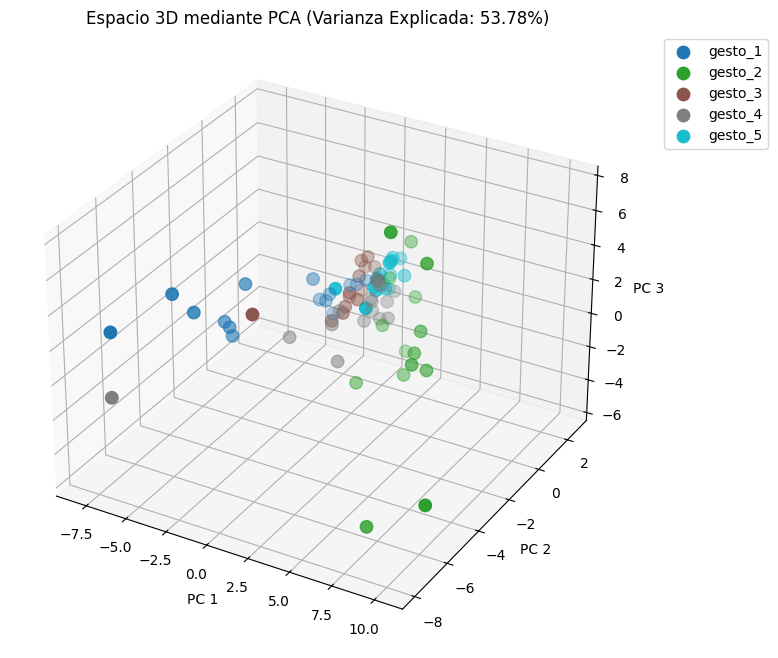

In [ ]:
# --- GRÁFICA 3D ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

gestos_unicos = y.unique()
colores = plt.cm.tab10(np.linspace(0, 1, len(gestos_unicos)))

for i, gesto in enumerate(gestos_unicos):
    mask = (y == gesto)
    ax.scatter(
        X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
        label=gesto, color=colores[i], s=80
    )

ax.set_title(f'Espacio 3D mediante PCA (Varianza Explicada: {sum(pca_3d.explained_variance_ratio_)*100:.2f}%)')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
# Dividir dataset (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_2d, y, test_size=0.20, random_state=42, stratify=y
)

print(f" Muestras totales: {len(X_pca_2d)}")
print(f" Muestras de Entrenamiento (Train): {len(X_train)}")
print(f" Muestras de Prueba (Test): {len(X_test)}")

 Muestras totales: 75
 Muestras de Entrenamiento (Train): 60
 Muestras de Prueba (Test): 15


 EVALUACIÓN DE VECINOS MÁS CERCANOS (k-NN con k=3)
Precisión global (Accuracy 2D): 80.00%

Reporte de Clasificación:
              precision    recall  f1-score   support

     gesto_1       0.67      0.67      0.67         3
     gesto_2       1.00      1.00      1.00         3
     gesto_3       0.75      1.00      0.86         3
     gesto_4       1.00      0.33      0.50         3
     gesto_5       0.75      1.00      0.86         3

    accuracy                           0.80        15
   macro avg       0.83      0.80      0.78        15
weighted avg       0.83      0.80      0.78        15



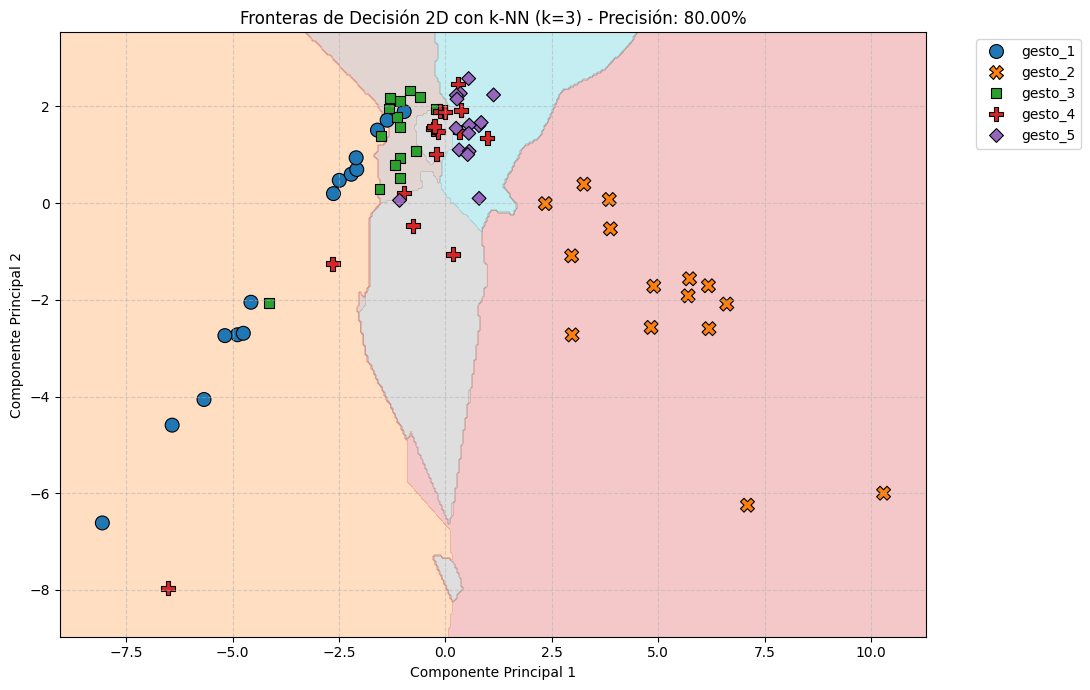

In [ ]:
from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsClassifier

# 1. Definir y entrenar el clasificador k-NN (k = 3 vecinos)
k = 3
knn_2d = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
knn_2d.fit(X_train, y_train)

# 2. Evaluar precisión en el conjunto de prueba
y_pred_knn = knn_2d.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn) * 100

print("===============================================")
print(f" EVALUACIÓN DE VECINOS MÁS CERCANOS (k-NN con k={k})")
print("===============================================")
print(f"Precisión global (Accuracy 2D): {acc_knn:.2f}%\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_knn))

# 3. Mapeo numérico de etiquetas para la malla de fondo
gestos_unicos = np.unique(y)
gesto_a_num = {g: i for i, g in enumerate(gestos_unicos)}
num_a_gesto = {i: g for i, g in enumerate(gestos_unicos)}

y_train_num = np.array([gesto_a_num[g] for g in y_train])

knn_num = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
knn_num.fit(X_train, y_train_num)

# 4. Crear la malla (mesh) para graficar las fronteras de decisión en 2D
h = 0.05  # Resolución de la malla
x_min, x_max = X_pca_2d[:, 0].min() - 1, X_pca_2d[:, 0].max() + 1
y_min, y_max = X_pca_2d[:, 1].min() - 1, X_pca_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predecir cada punto de la malla
Z = knn_num.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Graficar Fronteras de Decisión + Puntos de Datos
plt.figure(figsize=(11, 7))

# Colorear regiones del espacio según k-NN
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.25,
    cmap="tab10",
    levels=np.arange(len(gestos_unicos) + 1) - 0.5,
)

# Dibujar puntos reales
sns.scatterplot(
    x=X_pca_2d[:, 0],
    y=X_pca_2d[:, 1],
    hue=y,
    palette="tab10",
    style=y,
    s=100,
    edgecolor="k",
)

plt.title(
    f"Fronteras de Decisión 2D con k-NN (k={k}) - Precisión: {acc_knn:.2f}%"
)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

 EVALUACIÓN DE VECINOS MÁS CERCANOS EN 3D (k=3)
Precisión global (Accuracy 3D): 73.33%

Reporte de Clasificación en 3D:
              precision    recall  f1-score   support

     gesto_1       0.50      0.67      0.57         3
     gesto_2       1.00      1.00      1.00         3
     gesto_3       0.50      0.67      0.57         3
     gesto_4       1.00      0.33      0.50         3
     gesto_5       1.00      1.00      1.00         3

    accuracy                           0.73        15
   macro avg       0.80      0.73      0.73        15
weighted avg       0.80      0.73      0.73        15



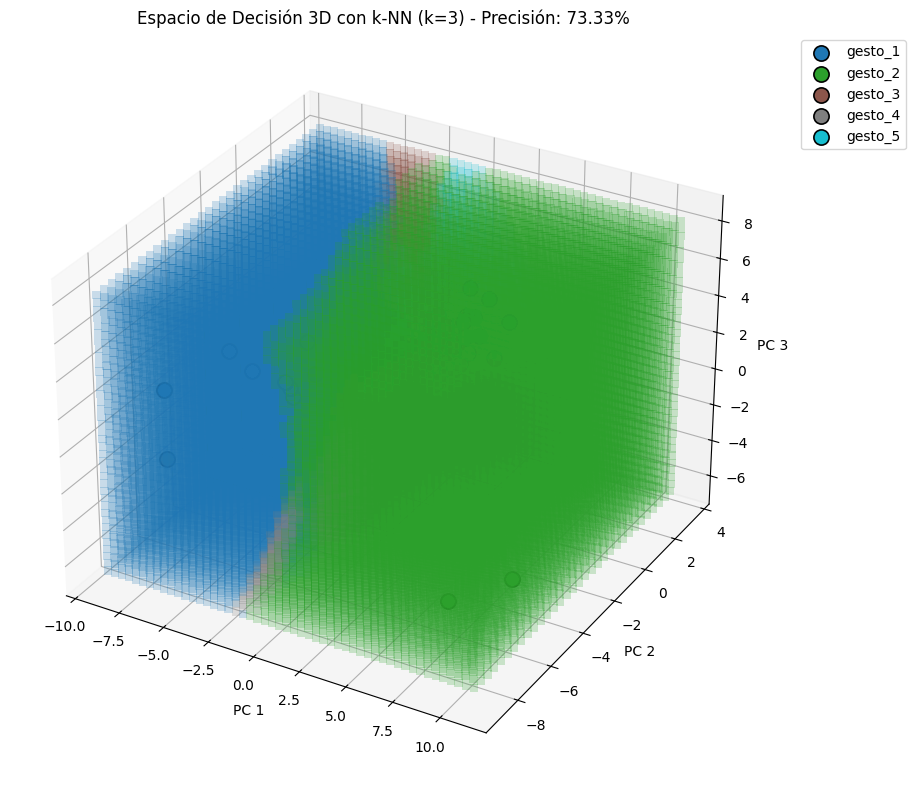

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Dividir los datos usando las 3 componentes del PCA
X_train_3d, X_test_3d, y_train, y_test = train_test_split(
    X_pca_3d, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Entrenar k-NN en el espacio 3D (k = 3)
k = 3
knn_3d = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
knn_3d.fit(X_train_3d, y_train)

# 3. Predecir y calcular precisión en 3D
y_pred_3d = knn_3d.predict(X_test_3d)
acc_3d = accuracy_score(y_test, y_pred_3d) * 100

print("===============================================")
print(f" EVALUACIÓN DE VECINOS MÁS CERCANOS EN 3D (k={k})")
print("===============================================")
print(f"Precisión global (Accuracy 3D): {acc_3d:.2f}%\n")
print("Reporte de Clasificación en 3D:")
print(classification_report(y_test, y_pred_3d))

# 4. Generar malla de puntos densa para definir los volúmenes de decisión
x_min, x_max = X_pca_3d[:, 0].min() - 1, X_pca_3d[:, 0].max() + 1
y_min, y_max = X_pca_3d[:, 1].min() - 1, X_pca_3d[:, 1].max() + 1
z_min, z_max = X_pca_3d[:, 2].min() - 1, X_pca_3d[:, 2].max() + 1

# Paso más fino para tupir el espacio sin saturar la memoria de Colab
paso = 0.4
gx, gy, gz = np.mgrid[x_min:x_max:paso, y_min:y_max:paso, z_min:z_max:paso]
puntos_malla = np.c_[gx.ravel(), gy.ravel(), gz.ravel()]

# Mapeo de colores por gesto
gestos_unicos = np.unique(y)
colores_dict = dict(zip(gestos_unicos, plt.cm.tab10(np.linspace(0, 1, len(gestos_unicos)))))

# Predicción del espacio tridimensional completo
predicciones_malla = knn_3d.predict(puntos_malla)
colores_malla = [colores_dict[g] for g in predicciones_malla]

# 5. Gráfica 3D con regiones sólidas y datos reales
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

# Volúmenes de decisión más tupidos y visibles
ax.scatter(
    puntos_malla[:, 0], puntos_malla[:, 1], puntos_malla[:, 2],
    c=colores_malla, alpha=0.22, marker='s', s=35, edgecolor='none'
)

# Muestras reales resaltadas con borde negro
for gesto in gestos_unicos:
    mask = (y == gesto)
    ax.scatter(
        X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
        label=gesto, color=colores_dict[gesto], s=120, edgecolors='k', linewidth=1.2, depthshade=False
    )

ax.set_title(f'Espacio de Decisión 3D con k-NN (k={k}) - Precisión: {acc_3d:.2f}%')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()